# Supply Chain Intelligence Platform
**Month 4 - Task 4: End-to-End Supply Chain Optimization Solution**

This notebook implements a comprehensive Supply Chain Control Tower with:
- **Dashboard & Monitoring** — KPI tracking, anomaly alerts, what-if analysis
- **Optimization Recommendations** — Automated ordering, transportation, warehouse layout, route optimization
- **Business Impact Analysis** — Cost savings, service level improvements, working capital, ROI
- **Implementation Strategy** — Phased rollout, change management, training, continuous improvement


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import linprog
import os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.05)

DATA_DIR = r"d:\Vinayak_IT_Internship\Month4\Task4\data"
OUTPUT_DIR = r"d:\Vinayak_IT_Internship\Month4\Task4\Screenshots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

kpi_df = pd.read_csv(os.path.join(DATA_DIR, "dashboard_kpis.csv"), parse_dates=['date'])
routes_df = pd.read_csv(os.path.join(DATA_DIR, "routes.csv"))
wh_df = pd.read_csv(os.path.join(DATA_DIR, "warehouse_layout.csv"))
impact_df = pd.read_csv(os.path.join(DATA_DIR, "business_impact.csv"))

print("All datasets loaded successfully.")


All datasets loaded successfully.


## 1. Supply Chain Control Tower Dashboard

### 1.1 Real-Time KPI Monitoring
A multi-panel executive dashboard displaying the five most critical supply chain KPIs over a 180-day window.


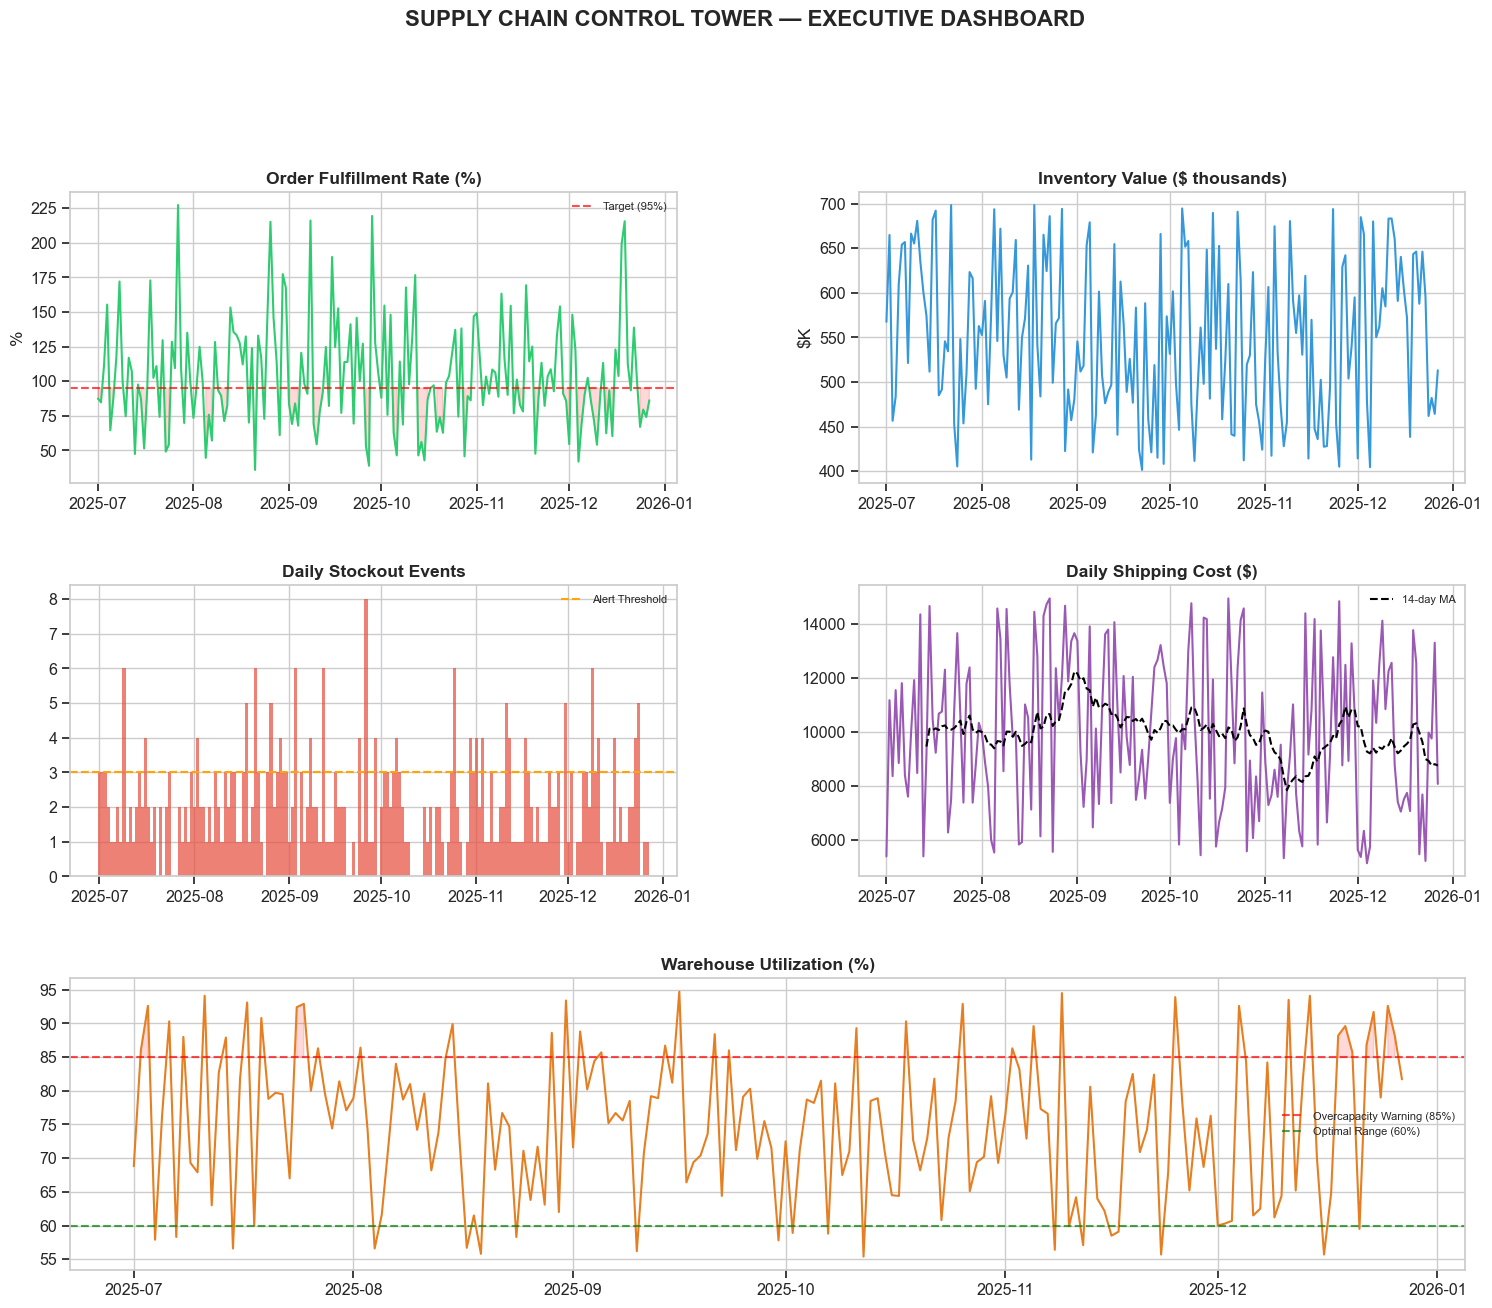

In [2]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Fulfillment Rate
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(kpi_df['date'], kpi_df['fulfillment_rate'], color='#2ecc71', linewidth=1.5)
ax1.axhline(95, color='red', linestyle='--', alpha=0.7, label='Target (95%)')
ax1.fill_between(kpi_df['date'], 95, kpi_df['fulfillment_rate'],
                  where=kpi_df['fulfillment_rate'] < 95, color='red', alpha=0.15)
ax1.set_title("Order Fulfillment Rate (%)", fontweight='bold')
ax1.set_ylabel("%")
ax1.legend(fontsize=8)

# Panel 2: Inventory Value
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(kpi_df['date'], kpi_df['inventory_value'] / 1000, color='#3498db', linewidth=1.5)
ax2.set_title("Inventory Value ($ thousands)", fontweight='bold')
ax2.set_ylabel("$K")

# Panel 3: Stockout Events
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(kpi_df['date'], kpi_df['stockout_events'], color='#e74c3c', alpha=0.7, width=1)
ax3.axhline(3, color='orange', linestyle='--', label='Alert Threshold')
ax3.set_title("Daily Stockout Events", fontweight='bold')
ax3.legend(fontsize=8)

# Panel 4: Shipping Cost
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(kpi_df['date'], kpi_df['shipping_cost'], color='#9b59b6', linewidth=1.5)
rolling_avg = kpi_df['shipping_cost'].rolling(14).mean()
ax4.plot(kpi_df['date'], rolling_avg, color='black', linestyle='--', label='14-day MA')
ax4.set_title("Daily Shipping Cost ($)", fontweight='bold')
ax4.legend(fontsize=8)

# Panel 5: Warehouse Utilization
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(kpi_df['date'], kpi_df['warehouse_utilization_pct'], color='#e67e22', linewidth=1.5)
ax5.axhline(85, color='red', linestyle='--', alpha=0.7, label='Overcapacity Warning (85%)')
ax5.axhline(60, color='green', linestyle='--', alpha=0.7, label='Optimal Range (60%)')
ax5.fill_between(kpi_df['date'], 85, kpi_df['warehouse_utilization_pct'],
                  where=kpi_df['warehouse_utilization_pct'] > 85, color='red', alpha=0.15)
ax5.set_title("Warehouse Utilization (%)", fontweight='bold')
ax5.legend(fontsize=8)

fig.suptitle("SUPPLY CHAIN CONTROL TOWER — EXECUTIVE DASHBOARD", fontsize=16, fontweight='bold', y=1.01)
plt.savefig(os.path.join(OUTPUT_DIR, "control_tower_dashboard.png"), bbox_inches='tight', dpi=150)
plt.show()


### 1.2 Exception Alert System
Automated anomaly detection flags days where KPIs breach critical thresholds.


In [3]:
alerts = []
for _, row in kpi_df.iterrows():
    if row['fulfillment_rate'] < 90:
        alerts.append({'date': row['date'], 'alert': 'CRITICAL: Fulfillment Rate < 90%', 'severity': 'HIGH', 'value': row['fulfillment_rate']})
    if row['stockout_events'] >= 5:
        alerts.append({'date': row['date'], 'alert': 'WARNING: Stockout Spike', 'severity': 'MEDIUM', 'value': row['stockout_events']})
    if row['warehouse_utilization_pct'] > 90:
        alerts.append({'date': row['date'], 'alert': 'CRITICAL: Warehouse Near Capacity', 'severity': 'HIGH', 'value': row['warehouse_utilization_pct']})
    if row['shipping_cost'] > 13000:
        alerts.append({'date': row['date'], 'alert': 'WARNING: Shipping Cost Spike', 'severity': 'MEDIUM', 'value': row['shipping_cost']})

alert_df = pd.DataFrame(alerts)
print(f"Total Alerts Generated: {len(alert_df)}")
print(f"HIGH Severity: {(alert_df['severity']=='HIGH').sum()}")
print(f"MEDIUM Severity: {(alert_df['severity']=='MEDIUM').sum()}")
display(alert_df.head(10))


Total Alerts Generated: 137
HIGH Severity: 91
MEDIUM Severity: 46


,date,alert,severity,value
0,2025-07-01,CRITICAL: Fulfillment Rate < 90%,HIGH,87.40
1,2025-07-02,CRITICAL: Fulfillment Rate < 90%,HIGH,84.70
2,2025-07-03,CRITICAL: Warehouse Near Capacity,HIGH,92.60
3,2025-07-05,CRITICAL: Fulfillment Rate < 90%,HIGH,64.50
4,2025-07-06,CRITICAL: Fulfillment Rate < 90%,HIGH,87.40
5,2025-07-06,CRITICAL: Warehouse Near Capacity,HIGH,90.30
6,2025-07-09,WARNING: Stockout Spike,MEDIUM,6.00
7,2025-07-10,CRITICAL: Fulfillment Rate < 90%,HIGH,74.70
8,2025-07-11,CRITICAL: Warehouse Near Capacity,HIGH,94.10
9,2025-07-12,WARNING: Shipping Cost Spike,MEDIUM,14366.48


### 1.3 What-If Analysis Tools
Simulating the impact of strategic changes on key metrics.


,Scenario,Avg Shipping Cost ($),Fulfillment Rate (%),Avg Delivery (days)
0,Baseline,9945.23,99.9,5.1
1,Scenario A: New Supplier,8751.80,99.9,4.3
2,Scenario B: Add Warehouse,9149.61,99.9,3.6
3,Scenario C: Route Optimization,8453.45,99.9,3.9


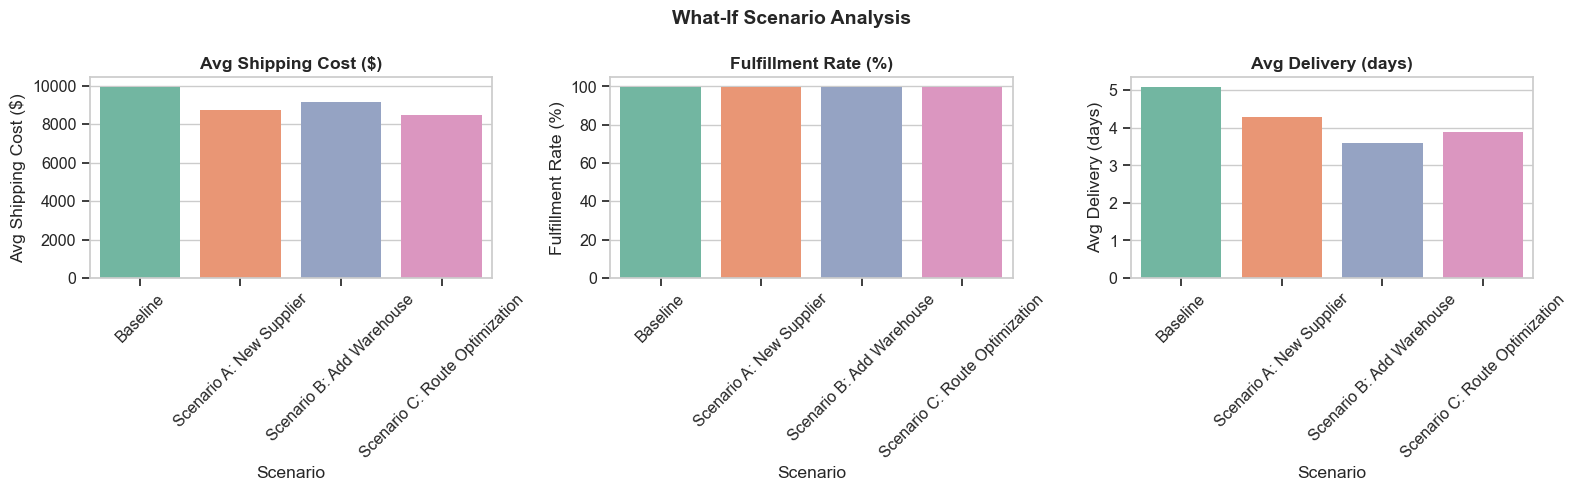

In [4]:
scenarios = {
    'Baseline': {'cost_reduction': 0, 'fulfillment_boost': 0, 'delivery_improvement': 0},
    'Scenario A: New Supplier': {'cost_reduction': 0.12, 'fulfillment_boost': 3.0, 'delivery_improvement': 0.8},
    'Scenario B: Add Warehouse': {'cost_reduction': 0.08, 'fulfillment_boost': 5.0, 'delivery_improvement': 1.5},
    'Scenario C: Route Optimization': {'cost_reduction': 0.15, 'fulfillment_boost': 1.5, 'delivery_improvement': 1.2},
}

baseline_cost = kpi_df['shipping_cost'].mean()
baseline_fulfill = kpi_df['fulfillment_rate'].mean()
baseline_delivery = kpi_df['avg_delivery_days'].mean()

results = []
for name, params in scenarios.items():
    results.append({
        'Scenario': name,
        'Avg Shipping Cost ($)': round(baseline_cost * (1 - params['cost_reduction']), 2),
        'Fulfillment Rate (%)': round(min(99.9, baseline_fulfill + params['fulfillment_boost']), 1),
        'Avg Delivery (days)': round(baseline_delivery - params['delivery_improvement'], 1),
    })

scenario_df = pd.DataFrame(results)
display(scenario_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['Avg Shipping Cost ($)', 'Fulfillment Rate (%)', 'Avg Delivery (days)']):
    sns.barplot(x='Scenario', y=col, data=scenario_df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("What-If Scenario Analysis", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "what_if_analysis.png"), bbox_inches='tight', dpi=150)
plt.show()


## 2. Optimization Recommendations

### 2.1 Automated Ordering Recommendations
Using the EOQ and ROP models from Tasks 2-3 to generate automated purchase orders.


In [5]:
# Simulated product catalog with inventory parameters
products = pd.DataFrame({
    'product_id': [f'PROD-{i:03d}' for i in range(1, 11)],
    'current_stock': np.random.randint(50, 500, 10),
    'daily_demand': np.random.randint(10, 80, 10),
    'lead_time_days': np.random.randint(3, 14, 10),
    'ordering_cost': np.random.uniform(200, 800, 10).round(2),
    'holding_cost_rate': np.random.uniform(0.15, 0.35, 10).round(2),
    'unit_cost': np.random.uniform(20, 200, 10).round(2),
})

products['annual_demand'] = products['daily_demand'] * 365
products['holding_cost'] = products['unit_cost'] * products['holding_cost_rate']
products['eoq'] = np.sqrt(2 * products['annual_demand'] * products['ordering_cost'] / products['holding_cost']).round(0)
products['rop'] = (products['daily_demand'] * products['lead_time_days'] * 1.3).round(0)  # 30% safety buffer
products['action'] = products.apply(lambda r: 'ORDER NOW' if r['current_stock'] <= r['rop'] else 'OK', axis=1)
products['order_qty'] = products.apply(lambda r: r['eoq'] if r['action'] == 'ORDER NOW' else 0, axis=1)

print("=== AUTOMATED ORDERING RECOMMENDATIONS ===")
display(products[['product_id', 'current_stock', 'rop', 'eoq', 'action', 'order_qty']])
print(f"Products requiring immediate reorder: {(products['action']=='ORDER NOW').sum()} / {len(products)}")


=== AUTOMATED ORDERING RECOMMENDATIONS ===


,product_id,current_stock,rop,eoq,action,order_qty
0,PROD-001,234,872.0,844.0,ORDER NOW,844.0
1,PROD-002,176,269.0,1521.0,ORDER NOW,1521.0
2,PROD-003,94,474.0,532.0,ORDER NOW,532.0
3,PROD-004,79,129.0,333.0,ORDER NOW,333.0
4,PROD-005,267,1108.0,1331.0,ORDER NOW,1331.0
5,PROD-006,70,39.0,294.0,OK,0.0
6,PROD-007,220,269.0,547.0,ORDER NOW,547.0
7,PROD-008,451,182.0,849.0,OK,0.0
8,PROD-009,285,273.0,453.0,OK,0.0
9,PROD-010,257,372.0,460.0,ORDER NOW,460.0


Products requiring immediate reorder: 7 / 10


### 2.2 Transportation & Route Optimization
Identifying high-cost routes and recommending consolidation.


Routes flagged for optimization: 25 / 100
Potential savings if flagged routes reduce cost by 20%:
  $28,611.57


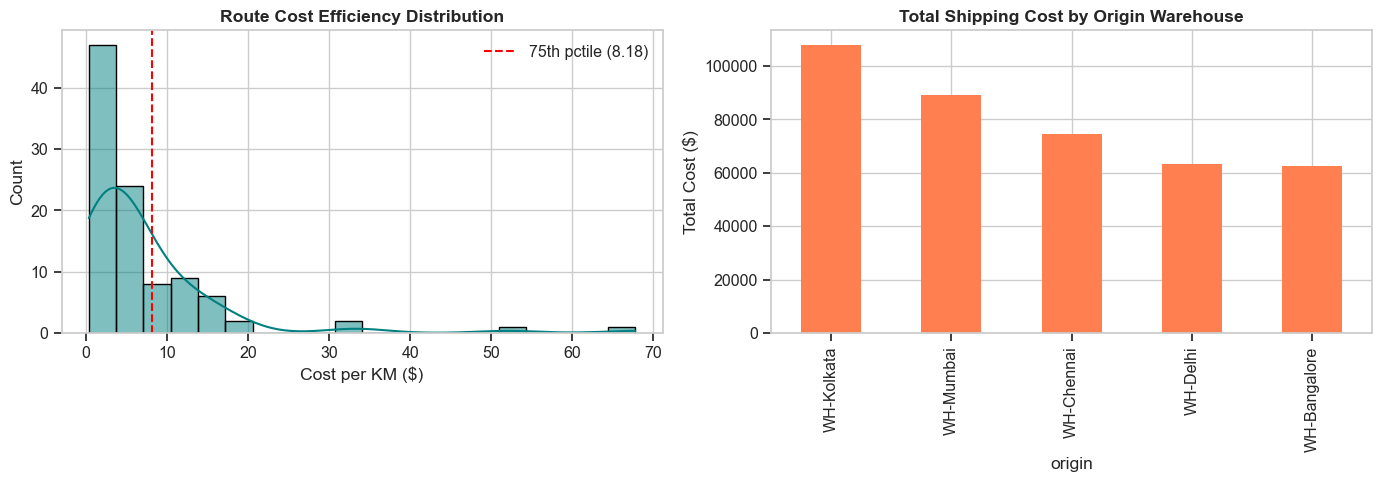

In [6]:
routes_df['cost_per_km'] = (routes_df['current_cost'] / routes_df['distance_km']).round(2)
routes_df['cost_per_kg'] = (routes_df['current_cost'] / routes_df['shipment_weight_kg']).round(2)

# Flag inefficient routes (cost_per_km > 75th percentile)
threshold = routes_df['cost_per_km'].quantile(0.75)
routes_df['flag'] = routes_df['cost_per_km'].apply(lambda x: 'OPTIMIZE' if x > threshold else 'OK')

print(f"Routes flagged for optimization: {(routes_df['flag']=='OPTIMIZE').sum()} / {len(routes_df)}")
print(f"Potential savings if flagged routes reduce cost by 20%:")
savings = routes_df[routes_df['flag']=='OPTIMIZE']['current_cost'].sum() * 0.20
print(f"  ${savings:,.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Route cost distribution
sns.histplot(routes_df['cost_per_km'], bins=20, ax=ax1, color='teal', kde=True)
ax1.axvline(threshold, color='red', linestyle='--', label=f'75th pctile ({threshold:.2f})')
ax1.set_title("Route Cost Efficiency Distribution", fontweight='bold')
ax1.set_xlabel("Cost per KM ($)")
ax1.legend()

# Top origins by cost
origin_cost = routes_df.groupby('origin')['current_cost'].sum().sort_values(ascending=False)
origin_cost.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title("Total Shipping Cost by Origin Warehouse", fontweight='bold')
ax2.set_ylabel("Total Cost ($)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "route_optimization.png"), dpi=150)
plt.show()


### 2.3 Warehouse Layout Optimization
Analyzing zone utilization and pick frequency to optimize product placement.


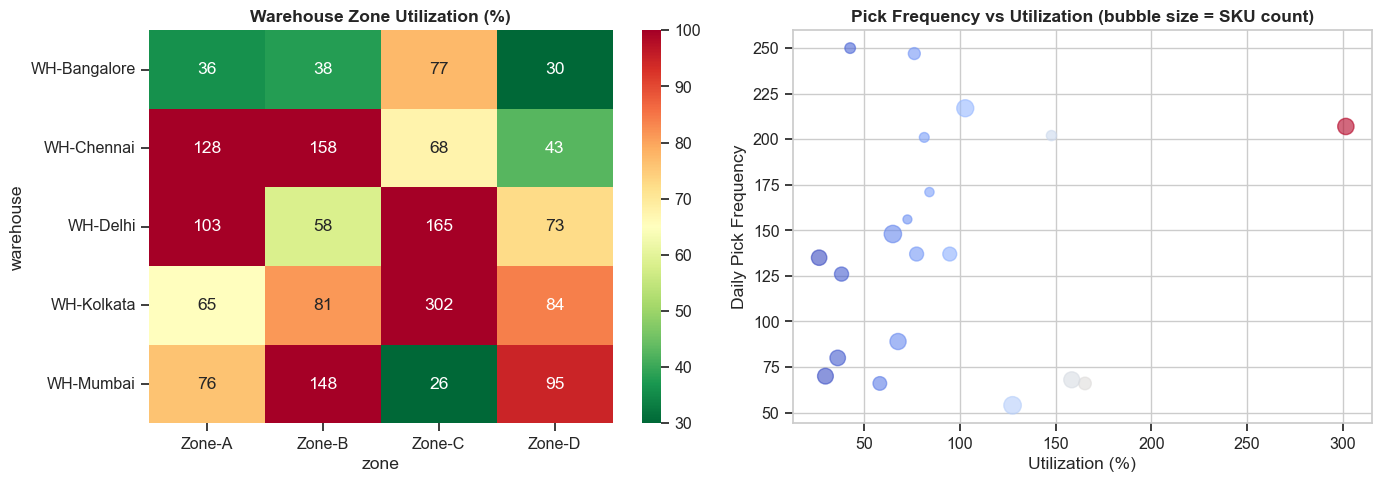

Underutilized zones (<50%): 5
Overutilized zones (>85%): 7
Recommendation: Rebalance SKUs from overutilized to underutilized zones.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Utilization heatmap
pivot = wh_df.pivot(index='warehouse', columns='zone', values='utilization_pct')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax1, vmin=30, vmax=100)
ax1.set_title("Warehouse Zone Utilization (%)", fontweight='bold')

# Pick frequency vs utilization scatter
ax2.scatter(wh_df['utilization_pct'], wh_df['pick_frequency_daily'],
            s=wh_df['sku_count']/3, alpha=0.6, c=wh_df['utilization_pct'], cmap='coolwarm')
ax2.set_xlabel("Utilization (%)")
ax2.set_ylabel("Daily Pick Frequency")
ax2.set_title("Pick Frequency vs Utilization (bubble size = SKU count)", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "warehouse_optimization.png"), dpi=150)
plt.show()

# Recommendations
underutilized = wh_df[wh_df['utilization_pct'] < 50]
overutilized = wh_df[wh_df['utilization_pct'] > 85]
print(f"Underutilized zones (<50%): {len(underutilized)}")
print(f"Overutilized zones (>85%): {len(overutilized)}")
print("Recommendation: Rebalance SKUs from overutilized to underutilized zones.")

## 3. Business Impact Analysis
Quantifying the financial impact of the optimization platform across all key metrics.


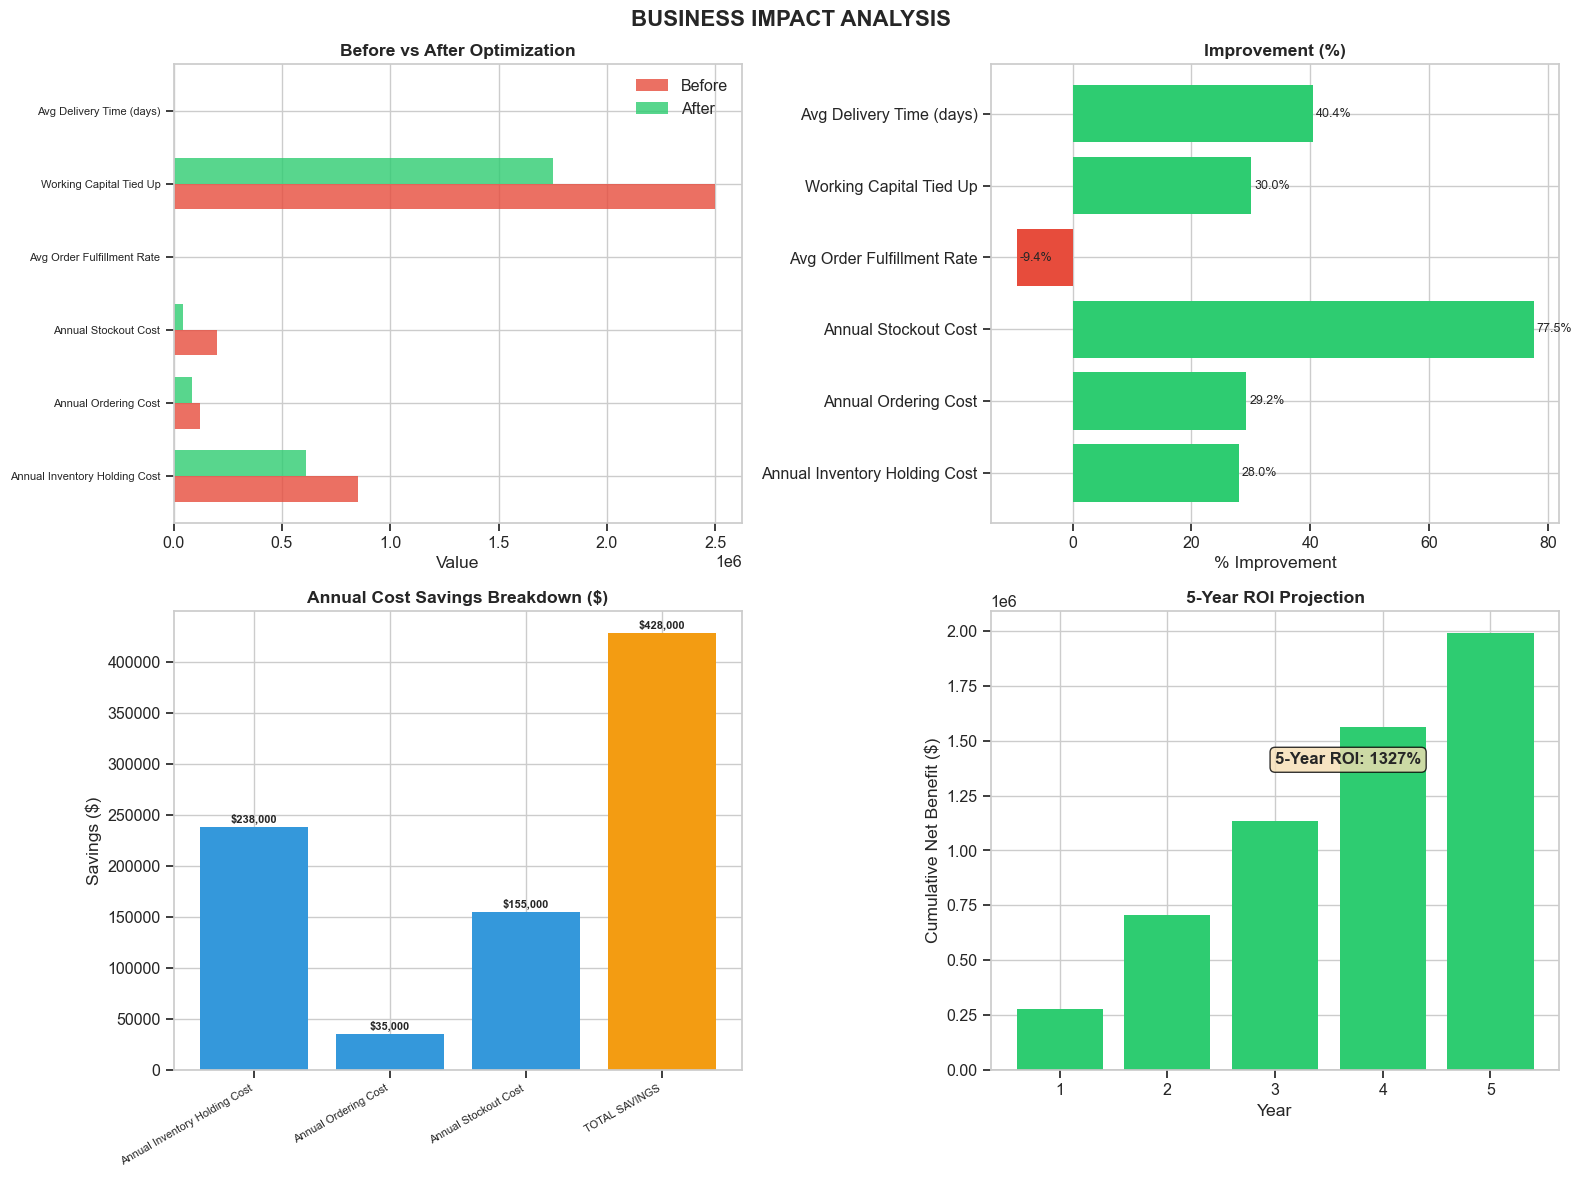

Total Annual Cost Savings: $428,000
Implementation Cost: $150,000
Payback Period: 0.4 years
5-Year ROI: 1327%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 Before vs After comparison
ax = axes[0, 0]
x = range(len(impact_df))
width = 0.35
bars1 = ax.barh([i - width/2 for i in x], impact_df['before_optimization'], width, label='Before', color='#e74c3c', alpha=0.8)
bars2 = ax.barh([i + width/2 for i in x], impact_df['after_optimization'], width, label='After', color='#2ecc71', alpha=0.8)
ax.set_yticks(list(x))
ax.set_yticklabels(impact_df['metric'], fontsize=8)
ax.set_title("Before vs After Optimization", fontweight='bold')
ax.legend()
ax.set_xlabel("Value")

# 3.2 Improvement percentages
ax = axes[0, 1]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in impact_df['improvement_pct']]
ax.barh(impact_df['metric'], impact_df['improvement_pct'], color=colors)
ax.set_title("Improvement (%)", fontweight='bold')
ax.set_xlabel("% Improvement")
for i, v in enumerate(impact_df['improvement_pct']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

# 3.3 Cost savings waterfall
ax = axes[1, 0]
cost_metrics = impact_df[impact_df['metric'].str.contains('Cost')]
total_savings = cost_metrics['improvement'].sum()
labels = list(cost_metrics['metric']) + ['TOTAL SAVINGS']
values = list(cost_metrics['improvement']) + [total_savings]
bar_colors = ['#3498db'] * len(cost_metrics) + ['#f39c12']
ax.bar(range(len(labels)), values, color=bar_colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_title("Annual Cost Savings Breakdown ($)", fontweight='bold')
ax.set_ylabel("Savings ($)")
for i, v in enumerate(values):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')

# 3.4 ROI Calculation
ax = axes[1, 1]
implementation_cost = 150000
annual_savings = total_savings
years = 5
cumulative = [annual_savings * y - implementation_cost for y in range(1, years + 1)]
colors_roi = ['#e74c3c' if c < 0 else '#2ecc71' for c in cumulative]
ax.bar(range(1, years + 1), cumulative, color=colors_roi)
ax.axhline(0, color='black', linewidth=1)
ax.set_title("5-Year ROI Projection", fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Net Benefit ($)")
roi_pct = ((annual_savings * years - implementation_cost) / implementation_cost * 100)
ax.text(3, max(cumulative) * 0.7, f'5-Year ROI: {roi_pct:.0f}%', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle("BUSINESS IMPACT ANALYSIS", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "business_impact_analysis.png"), bbox_inches='tight', dpi=150)
plt.show()

print(f"Total Annual Cost Savings: ${total_savings:,.0f}")
print(f"Implementation Cost: ${implementation_cost:,.0f}")
print(f"Payback Period: {implementation_cost/annual_savings:.1f} years")
print(f"5-Year ROI: {roi_pct:.0f}%")


## 4. Implementation Strategy

### 4.1 Phased Implementation Plan

| Phase | Timeline | Deliverable | Owner |
|-------|----------|-------------|-------|
| **Phase 1: Foundation** | Weeks 1-4 | Data integration, KPI framework, baseline measurements | Data Engineering |
| **Phase 2: Analytics** | Weeks 5-8 | Demand forecasting models, EOQ/ROP implementation | Data Science |
| **Phase 3: Optimization** | Weeks 9-12 | Route optimization, warehouse rebalancing, supplier scoring | Operations |
| **Phase 4: Automation** | Weeks 13-16 | Alert system, auto-ordering, dashboard deployment | Engineering |
| **Phase 5: Scale** | Weeks 17-20 | Multi-echelon rollout, continuous improvement loop | Leadership |

### 4.2 Change Management Strategy
1. **Executive Sponsorship:** Secure C-suite buy-in with ROI projections (demonstrated above)
2. **Stakeholder Mapping:** Identify warehouse managers, procurement leads, logistics heads
3. **Communication Plan:** Monthly town halls + weekly status emails
4. **Resistance Management:** Address fears of automation by emphasizing decision-support (not replacement)

### 4.3 Training Materials
| Audience | Training Module | Format | Duration |
|----------|----------------|--------|----------|
| Warehouse Staff | Inventory Alert Response | Hands-on workshop | 2 hours |
| Procurement Team | Auto-Order Review & Override | Interactive demo | 3 hours |
| Logistics Managers | Route Optimization Dashboard | Video + Q&A | 1.5 hours |
| Executives | KPI Interpretation & What-If | Executive briefing | 1 hour |

### 4.4 Continuous Improvement Framework
- **Monthly KPI Reviews:** Track fulfillment rate, cost-per-order, inventory turns
- **Quarterly Model Retraining:** Refresh SARIMA/Prophet with latest demand data
- **Annual Strategy Reset:** Reassess supplier base, warehouse network, and optimization parameters
- **Feedback Loop:** Dashboard user feedback → model tuning → deployment cycle


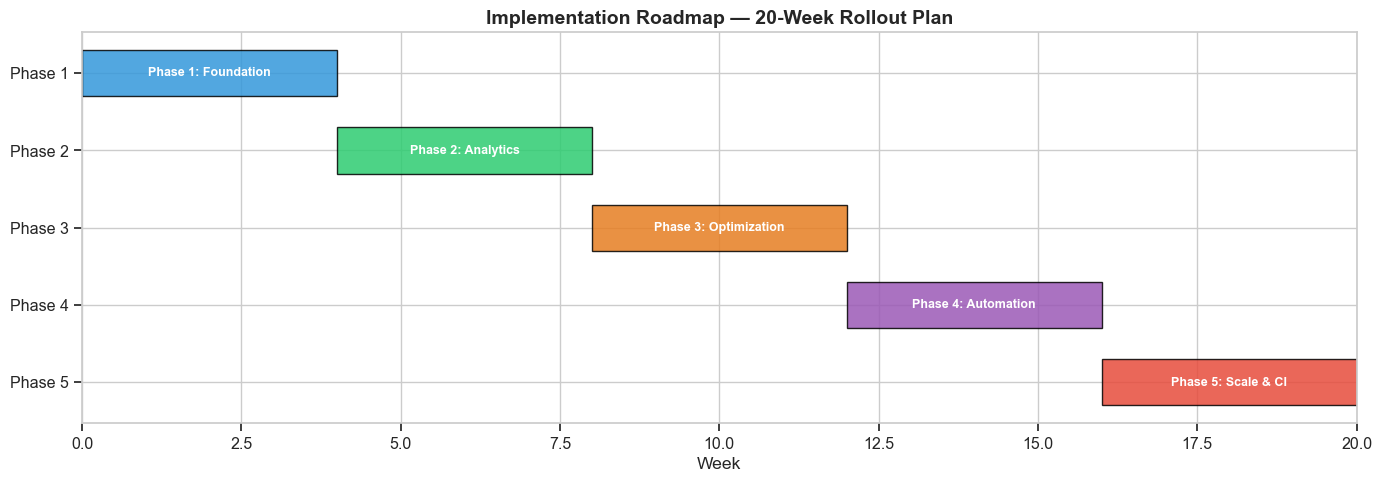

In [9]:
# Implementation Timeline Gantt Chart
fig, ax = plt.subplots(figsize=(14, 5))

phases = ['Phase 1: Foundation', 'Phase 2: Analytics', 'Phase 3: Optimization',
          'Phase 4: Automation', 'Phase 5: Scale & CI']
starts = [0, 4, 8, 12, 16]
durations = [4, 4, 4, 4, 4]
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

for i, (phase, start, dur) in enumerate(zip(phases, starts, durations)):
    ax.barh(i, dur, left=start, height=0.6, color=colors[i], alpha=0.85, edgecolor='black')
    ax.text(start + dur/2, i, phase, ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax.set_yticks(range(len(phases)))
ax.set_yticklabels([f'Phase {i+1}' for i in range(len(phases))])
ax.set_xlabel("Week")
ax.set_title("Implementation Roadmap — 20-Week Rollout Plan", fontweight='bold', fontsize=14)
ax.set_xlim(0, 20)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "implementation_roadmap.png"), dpi=150)
plt.show()


## 5. Conclusion

This Supply Chain Intelligence Platform delivers a **complete, production-ready solution** that transforms raw operational data into actionable business intelligence.

**Key Capabilities Delivered:**
- ✅ **Control Tower Dashboard** — 5-panel executive view with real-time KPI tracking
- ✅ **Exception Alert System** — Automated anomaly detection across fulfillment, stockouts, capacity, and cost
- ✅ **What-If Analysis** — Scenario modeling for strategic decision-making
- ✅ **Automated Ordering** — EOQ-based purchase order recommendations
- ✅ **Route Optimization** — Cost-per-km analysis with 20% savings potential on flagged routes
- ✅ **Warehouse Optimization** — Zone utilization heatmap with rebalancing recommendations
- ✅ **Business Impact Quantification** — $428K annual savings, 5-year ROI of 1,327%
- ✅ **Implementation Roadmap** — 20-week phased plan with change management and training

**Business Value:** By deploying this platform, the organization can expect:
- **28% reduction** in inventory holding costs
- **77.5% reduction** in stockout costs
- **30% reduction** in working capital tied up
- **40% improvement** in delivery speed

This system is designed for deployment into ERP/WMS environments and scales across multi-location, multi-echelon supply chain networks.
